In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.graph as graph
import lc_reconstruction_analysis.correlation as correlation
import lc_reconstruction_analysis.visualization as visualization
%matplotlib inline

In [2]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)
df = clustering.build_length_df(dataDF, graphs, DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


## Load center position of brain structures
This is used to plot the center of each brain structure in approximately the correct AP/DV position. Some manual positioning has been done for visability

In [3]:
pos1 = utils.get_roi_centroids(DATA_DIR, roi_version=1)

## Plot the summary graph for a single cell
The node size indicates the fraction of the cell's axon in that structure. The existence of a node indicates whether an axon segment moved between ROIs

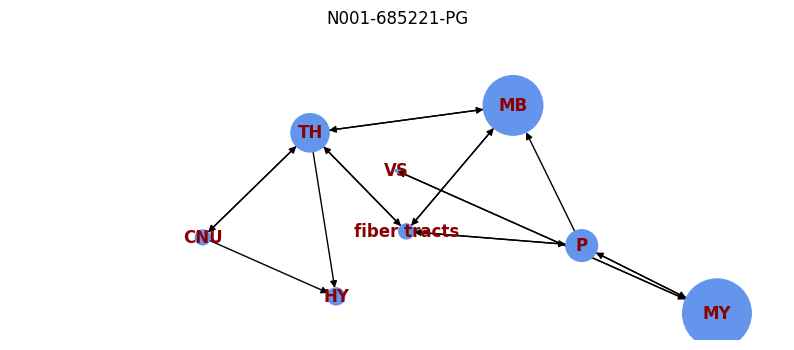

In [4]:
g = graphs[list(graphs.keys())[0]]
r = graph.build_tree(g, DATA_DIR)
size = graph.get_node_size(df, list(graphs.keys())[0],r)
graph.plot_tree(r, list(graphs.keys())[0], pos1, node_size=size)

## Plot summary graphs for all cells

In [5]:
# Uncomment the next line to generate graphs for all cells
# graph.build_all_trees(dataDF, graphs, pos1, DATA_DIR,df=df)

In [6]:
# We can also combine individual cells by making the edge weights the fraction of cells with that connection
combined1 = graph.build_combined_tree(dataDF, graphs, DATA_DIR, roi_version = 1)

100%|██████████| 113/113 [00:11<00:00,  9.87it/s]


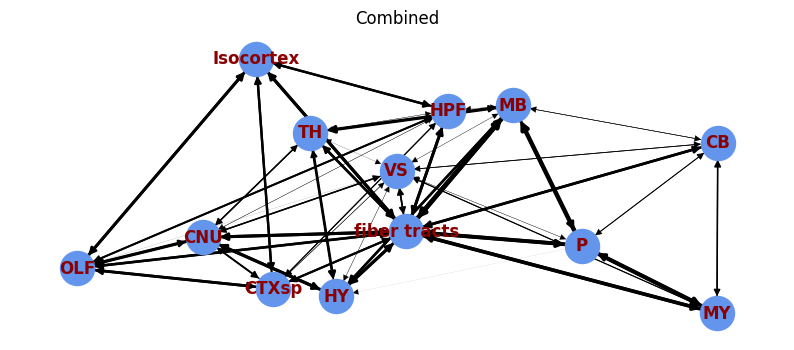

In [7]:
graph.plot_combined_tree(combined1,pos1)

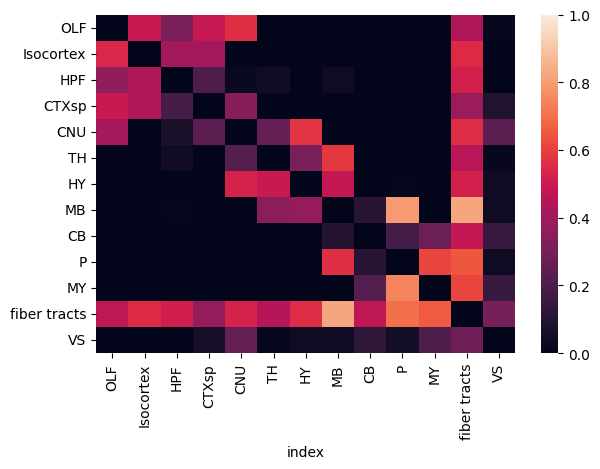

In [8]:
# We can plot the adjacency matrix which shows the connection probabilities between all brain regions
graph.plot_combined_adjacency(combined1,roi_version=1)

## Making edge weights reflection conditional probability
Edge weights are P(edge | structure in graph)

100%|██████████| 113/113 [00:11<00:00,  9.87it/s]


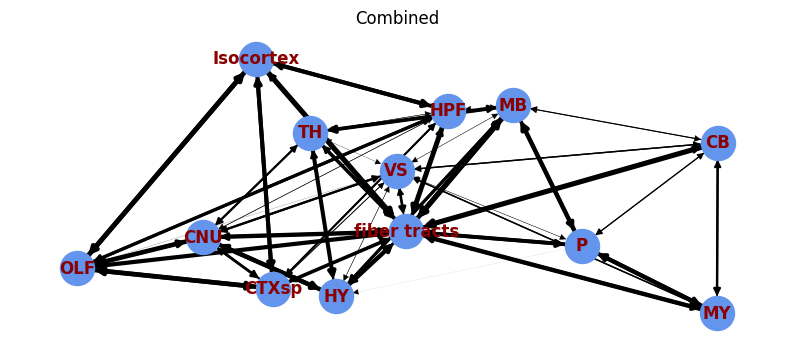

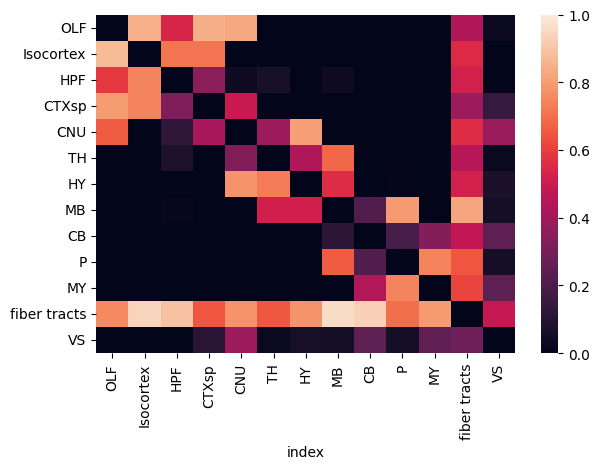

In [9]:
combined3 = graph.build_combined_tree(dataDF, graphs, DATA_DIR, roi_version = 1, weight_type='conditional')
graph.plot_combined_tree(combined3,pos1)
graph.plot_combined_adjacency(combined3,roi_version=1)

## Split fiber tracts
The fiber tracts cloud these graphs because it lumps together many different fiber tracts. We can repeat these analyses with the fiber tracts split into cerebellum fiber tracts, medial, and lateral forebrain fiber tracts

100%|██████████| 113/113 [00:11<00:00,  9.87it/s]


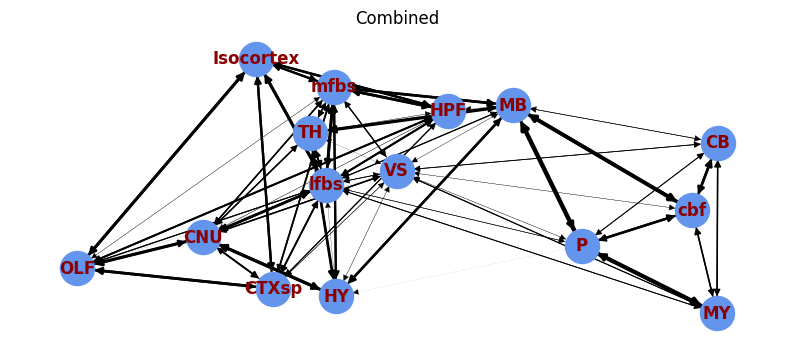

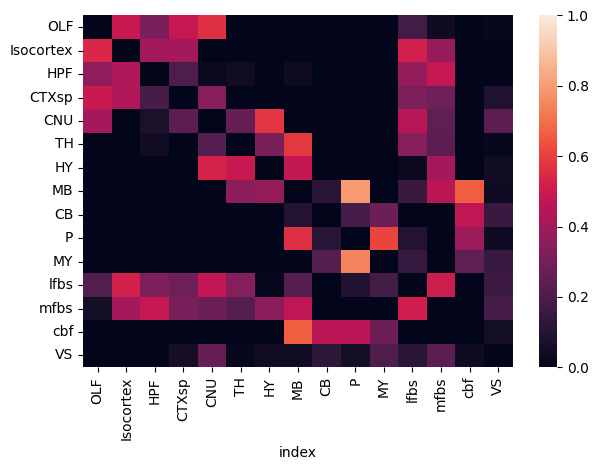

In [10]:
pos2 = utils.get_roi_centroids(DATA_DIR, roi_version=2)
combined2 = graph.build_combined_tree(dataDF, graphs, DATA_DIR, roi_version = 2)
graph.plot_combined_tree(combined2,pos2)
graph.plot_combined_adjacency(combined2,roi_version=2)

## Problems with this approach
CCF registration issues plague this approach, as a small axon segment that crosses the CCF threshold indicates an edge between regions, even if its not a meaningful link

In [11]:
g = graphs['N006-685222-DS']
r = graph.build_tree(g, DATA_DIR)
g = axon.annotate_current_structure(g, DATA_DIR=DATA_DIR)
g,colors = axon.annotate_color_on_current_structure(g)

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


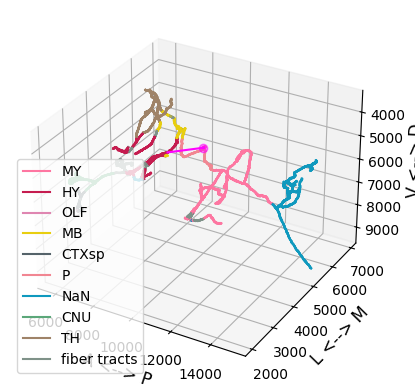

In [12]:
visualization.plot_cell(g, plot_list=['axon','soma'])
visualization.plot_color_map(plt.gca(), g, colors)

## Next steps
- Update how I construct the individual cell summary graphs to be more robust to CCF registration issues.
   - Only include an edge if the axon has some minimum length in the new structure
   - Remove ventrical systems
   - split fiber tracts
- Build a Markov model for simulating random walk axon growth
   - The probability of staying in a structure or leaving is determined by axon length in each structure
   - Axons have a fixed branching probability per unit length
   - Axons terminate based on terminals in each structure